# **IMAGE SEGMENTATION USING MASK2FORMER**
##BY UBONG CAMILUS BEN

Description:
In this task, we would be using Meta AI's transformer to perform image segmentation. For this project we would use:

- Semantic Segmentation
- Instant Segmentation
- Panoptic Segmentation


**About Mask2Former:**

Mask2Former constitutes a universal image segmentation architecture proposed by Meta AI Research in 2022. It is engineered to address all principal segmentation paradigms—namely semantic, instance, and panoptic segmentation—within a single, unified framework. The model extends the foundational MaskFormer architecture by integrating novel methodological enhancements that augment both segmentation performance and computational efficiency.


In [ ]:
#Requirements: Uncomment if you do not have these libraries
#! uv pip install transformers torch scipy matplotlib opencv-python pillow scikit-image

# Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.measure import regionprops

import torch
from PIL import Image
import requests

from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# Helper Function

In [2]:
def render_segmentation_overlay(prediction_output, input_image, segmentation_model, transparency=0.4):
    """
    Renders the segmentation mask on top of the original image,
    displaying colored regions for each segment and a legend indicating
    the object names and confidence scores.
    """
    # Extract segmentation mask array and metadata
    seg_mask = prediction_output["segmentation"].numpy()
    segment_metadata = prediction_output["segments_info"]
    img_height, img_width = seg_mask.shape

    # Initialize a blank RGB mask for coloring each segment
    rgb_overlay_mask = np.zeros((img_height, img_width, 3), dtype=np.uint8)

    # Assign a random RGB color to each segment ID
    segment_colors = {}
    for metadata in segment_metadata:
        segment_colors[metadata["id"]] = np.random.randint(0, 255, size=3)

    # Apply colors to each segment in the overlay mask
    for metadata in segment_metadata:
        segment_pixels = seg_mask == metadata["id"]
        rgb_overlay_mask[segment_pixels] = segment_colors[metadata["id"]]

    # Convert original image to NumPy array
    img_array = np.asarray(input_image, dtype=np.uint8)

    # Blend original image with colored mask using transparency factor
    blended_image = (1 - transparency) * img_array + transparency * rgb_overlay_mask
    blended_image = blended_image.astype(np.uint8)

    # Display blended image
    plt.figure(figsize=(12, 8))
    plt.imshow(blended_image)
    axes = plt.gca()
    plt.axis("off")

    # Draw color legend on right side of the figure
    current_y = 10
    bar_height = 25
    vertical_spacing = 10
    for metadata in segment_metadata:
        label_text = segmentation_model.config.id2label[metadata["label_id"]]
        color_norm = segment_colors[metadata["id"]] / 255.0

        # Draw a colored rectangle
        rectangle = mpatches.Rectangle(
            (img_width - 30, current_y),
            20,
            bar_height,
            facecolor=color_norm,
            edgecolor=None,
            linewidth=0,
            transform=axes.transData,
            clip_on=False
        )
        axes.add_patch(rectangle)

        # Draw text label with object name and confidence score
        axes.text(
            img_width - 35,
            current_y + bar_height / 2,
            f"{label_text} ({metadata['score']:.2f})",
            va="center",
            ha="right",
            fontsize=11,
            color="white" if np.mean(color_norm) < 0.5 else "black",
            bbox=dict(facecolor=(0, 0, 0, 0.2), edgecolor="none", boxstyle="round,pad=0.2")
        )
        current_y += bar_height + vertical_spacing

    plt.show()


def plot_segmentation_labels(prediction_output, segmentation_model):
    """
    Visualizes a segmentation mask by plotting segment IDs and displaying
    the corresponding object labels at the centroid of each region.
    """
    # Retrieve the segmentation array
    seg_data = prediction_output["segmentation"]
    segment_metadata = prediction_output["segments_info"]

    # Convert to NumPy if needed
    seg_array = seg_data.numpy() if hasattr(seg_data, "numpy") else np.array(seg_data)

    # Show the segmentation mask
    plt.figure(figsize=(15, 10))
    plt.imshow(seg_array)
    axes = plt.gca()

    # Iterate over segments to compute centroids and annotate labels
    for metadata in segment_metadata:
        seg_id = metadata["id"]
        label_id = metadata["label_id"]
        label_text = segmentation_model.config.id2label[label_id]

        # Create binary mask for current segment
        binary_mask = seg_array == seg_id

        # Use regionprops to find centroid
        props = regionprops(binary_mask.astype(np.uint8))
        if props:
            centroid_y, centroid_x = props[0].centroid
            axes.text(
                centroid_x,
                centroid_y,
                label_text,
                color="white",
                fontsize=8,
                weight="bold",
                ha="center",
                va="center",
                bbox=dict(facecolor="black", alpha=0.5, boxstyle="round,pad=0.2")
            )

    plt.axis("off")
    plt.show()


def display_semantic_segmentation(semantic_map, base_image, segmentation_model, transparency=0.5):
    """
    Overlays a semantic segmentation mask on top of the base image.
    Each label is assigned a random color for visualization.
    """
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

    # Create a random color palette for all labels
    total_labels = len(segmentation_model.config.id2label)
    color_palette = np.random.randint(0, 255, (total_labels, 3))
    colored_mask = np.zeros((*semantic_map.shape, 3), dtype=np.uint8)

    # Assign colors to each unique label
    unique_labels = torch.unique(semantic_map)
    for label_value in unique_labels:
        colored_mask[semantic_map == label_value] = color_palette[label_value]

    # Convert original image and blend with colored mask
    base_array = np.array(base_image)
    blended_output = (1 - transparency) * base_array + transparency * colored_mask
    blended_output = blended_output.astype(np.uint8)

    # Display the blended image
    plt.figure(figsize=(15, 10))
    plt.imshow(blended_output)
    plt.axis("off")
    plt.show()


In [3]:
# url = "https://i.pinimg.com/736x/1e/de/d8/1eded82fbcfc288327d9f12795dbab7b.jpg"
#url = "https://i.pinimg.com/736x/da/c6/12/dac612292f2cb04c82d6b41fdb6a1c6a.jpg"
# url = "https://i.pinimg.com/736x/4e/9f/7b/4e9f7ba5e373204ce3a0737494ab76c3.jpg"
# url = "https://i.pinimg.com/736x/9a/67/16/9a6716e63ff0afb1cee5931ade66e388.jpg"
#url = "https://i.pinimg.com/736x/59/e6/ae/59e6ae53b2bcee83dd57e4e3b1ce7d7c.jpg"
#url = "https://i.pinimg.com/736x/07/18/53/07185391756d6eef0ef73ea9d0b56ef9.jpg"
#url = "https://i.pinimg.com/736x/16/4f/21/164f213bb141fa9957926531d4056ceb.jpg"
url='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRd6hQipC9Nq93ACMHBawazSvg853s0Yfh7zA&s'
#url='//content//Screenshot 2025-07-15 005650.png'

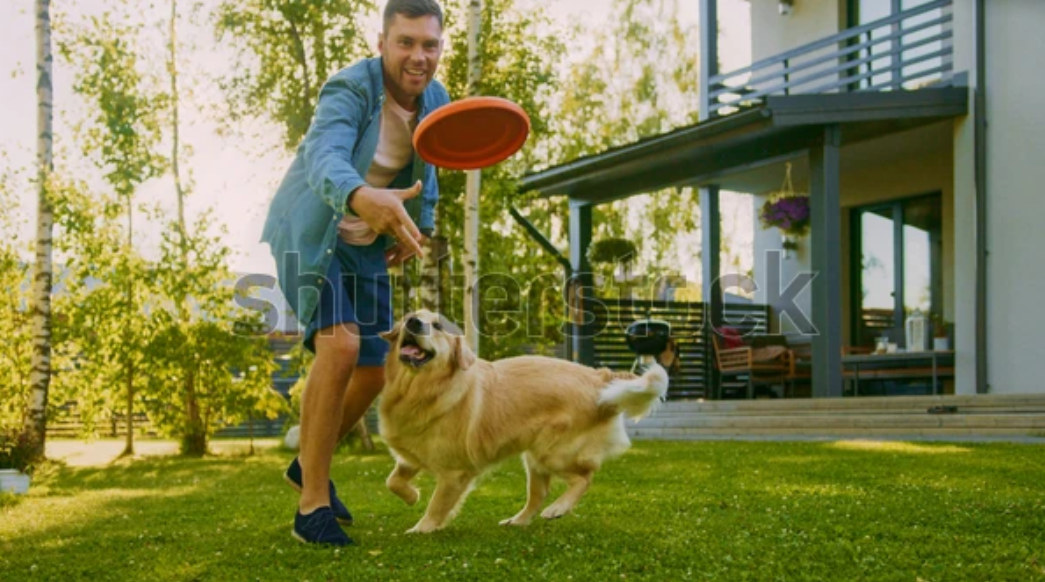

In [ ]:
Image.open(requests.get(url,stream=True).raw)

# 1.0   SEMANTIC SEGMENTATION

In [ ]:
def perform_semantic_segmentation(image_input_path):
    """
    Performs semantic segmentation inference using a pretrained Mask2Former model
    trained on the ADE20K dataset. It loads an image, processes it, and produces
    a segmentation label map resized to the original image dimensions.
    """
    # Specify the pretrained model checkpoint to use
    pretrained_checkpoint = "facebook/mask2former-swin-large-ade-semantic"

    # Load the AutoImageProcessor for preprocessing
    processor_instance = AutoImageProcessor.from_pretrained(pretrained_checkpoint)

    # Load the segmentation model
    segmentation_instance = Mask2FormerForUniversalSegmentation.from_pretrained(pretrained_checkpoint)

    # Load image from URL or local file
    if image_input_path.startswith("http"):
        loaded_image = Image.open(requests.get(image_input_path, stream=True).raw)
    else:
        loaded_image = Image.open(image_input_path).convert("RGB")

    # Preprocess image to create input tensors for the model
    processed_inputs = processor_instance(images=loaded_image, return_tensors="pt")

    # Perform inference without tracking gradients
    with torch.no_grad():
        prediction_outputs = segmentation_instance(**processed_inputs)

    # Convert raw logits to semantic label map with original image size
    segmentation_map = processor_instance.post_process_semantic_segmentation(
        prediction_outputs,
        target_sizes=[loaded_image.size[::-1]]
    )[0]

    # Return the segmentation map, loaded image, and model instance
    return segmentation_map, loaded_image, segmentation_instance


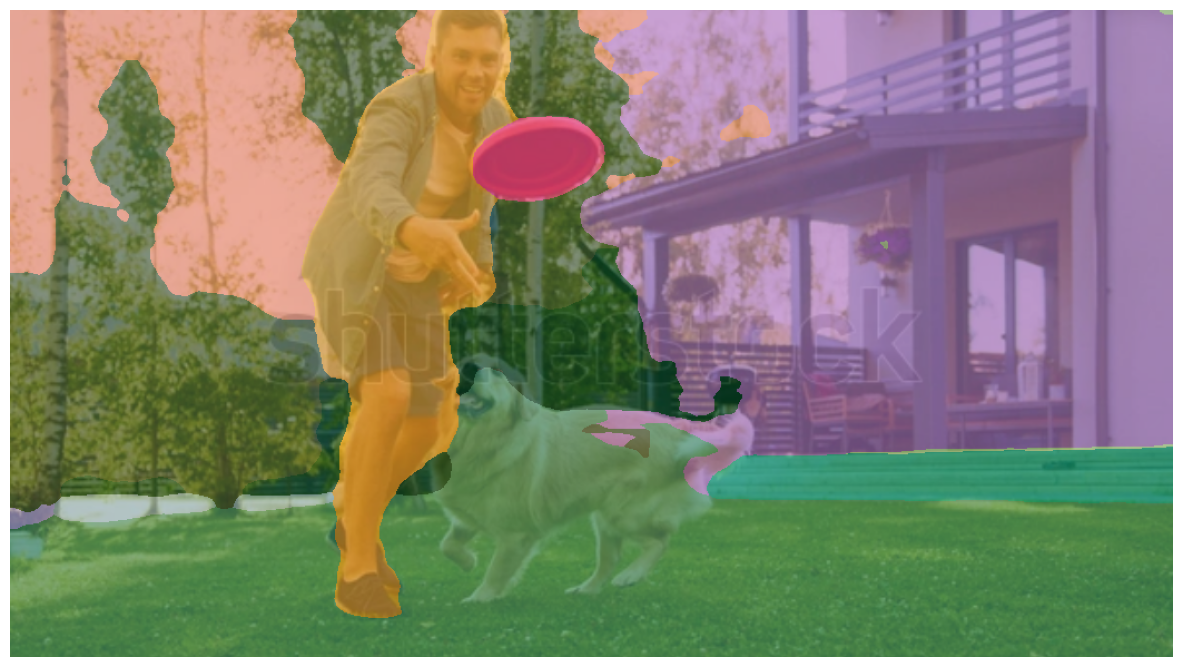

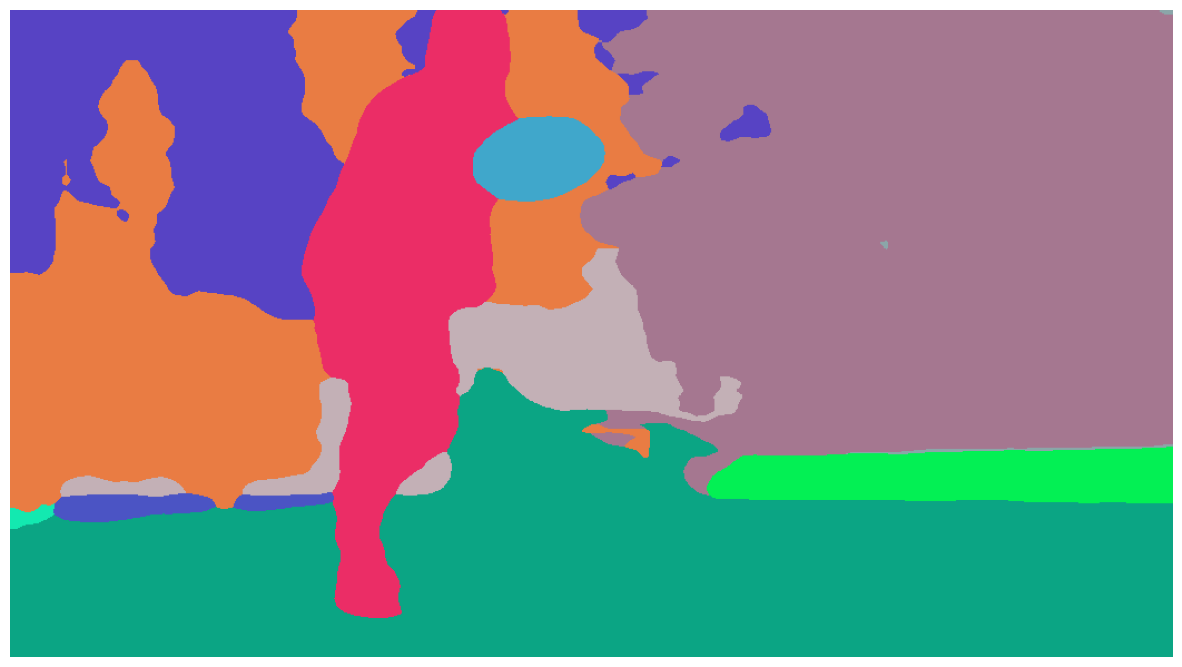

In [ ]:
# Semantic segmentation
segmentation_map, loaded_image, segmentation_instance = perform_semantic_segmentation(url)

display_semantic_segmentation(segmentation_map, loaded_image, segmentation_instance, transparency=0.6)
display_semantic_segmentation(segmentation_map, loaded_image, segmentation_instance, transparency=1.0)



# INSTANCE SEGMENTATION

In [ ]:
def perform_instance_segmentation(image_input_path):
    """
    Performs instance segmentation on an input image using a pretrained Mask2Former model
    trained on the COCO dataset. It returns the segmentation results, the original image,
    and the model instance for downstream visualization.
    """
    # Define the pretrained checkpoint for COCO instance segmentation
    pretrained_checkpoint = "facebook/mask2former-swin-large-coco-instance"

    # Load the processor and the segmentation model
    processor_instance = AutoImageProcessor.from_pretrained(pretrained_checkpoint)
    segmentation_instance = Mask2FormerForUniversalSegmentation.from_pretrained(pretrained_checkpoint)

    # Load the input image (supports URL or local file)
    if image_input_path.startswith("http"):
        loaded_image = Image.open(requests.get(image_input_path, stream=True).raw).convert("RGB")
    else:
        loaded_image = Image.open(image_input_path).convert("RGB")

    # Preprocess image and create input tensors
    processed_inputs = processor_instance(images=loaded_image, return_tensors="pt")

    # Perform inference without gradients
    with torch.no_grad():
        prediction_outputs = segmentation_instance(**processed_inputs)

    # Convert raw model outputs into instance segmentation results
    instance_results = processor_instance.post_process_instance_segmentation(
        prediction_outputs,
        target_sizes=[loaded_image.size[::-1]]
    )[0]

    # Return the results, image, and model for visualization
    return instance_results, loaded_image, segmentation_instance


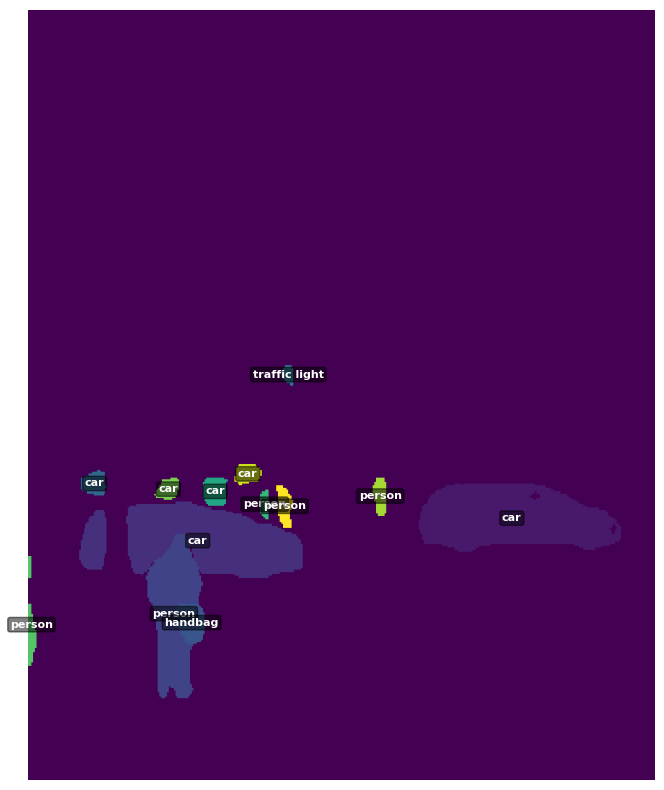

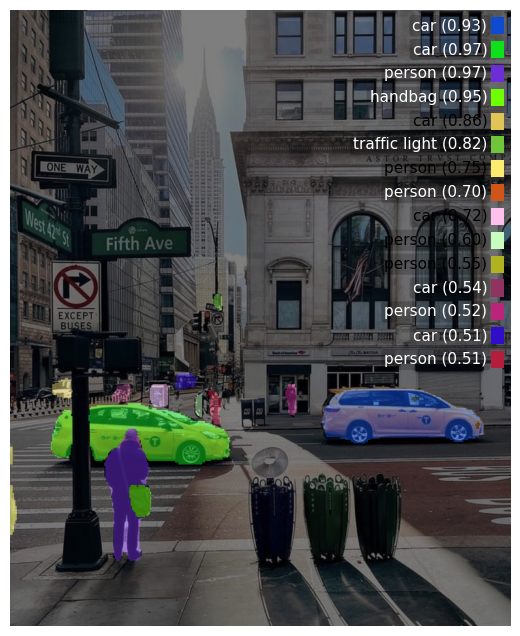

In [ ]:
# Instance segmentation

# Instance segmentation
instance_results, loaded_image, segmentation_instance = perform_instance_segmentation(url)

plot_segmentation_labels(instance_results, segmentation_instance)
render_segmentation_overlay(instance_results, loaded_image, segmentation_instance, transparency=0.5)


# 3.0   PANOPTIC SEGMENTATION

In [4]:
def perform_panoptic_segmentation(image_input_path):
    """
    Executes panoptic segmentation on an input image using a pretrained Mask2Former model
    trained on the COCO dataset. Returns segmentation results, the image object, and the model.
    """
    # Define the pretrained checkpoint for COCO panoptic segmentation
    pretrained_checkpoint = "facebook/mask2former-swin-base-coco-panoptic"

    # Load the processor and the segmentation model
    processor_instance = AutoImageProcessor.from_pretrained(pretrained_checkpoint)
    segmentation_instance = Mask2FormerForUniversalSegmentation.from_pretrained(pretrained_checkpoint)

    # Load the input image (supports URL or local file)
    if image_input_path.startswith("http"):
        loaded_image = Image.open(requests.get(image_input_path, stream=True).raw)
    else:
        loaded_image = Image.open(image_input_path)

    # Preprocess the image to create input tensors
    processed_inputs = processor_instance(images=loaded_image, return_tensors="pt")

    # Perform inference without computing gradients
    with torch.no_grad():
        prediction_outputs = segmentation_instance(**processed_inputs)

    # Convert raw model outputs into panoptic segmentation results
    panoptic_results = processor_instance.post_process_panoptic_segmentation(
        prediction_outputs,
        target_sizes=[loaded_image.size[::-1]]
    )[0]

    # Return results, image, and model
    return panoptic_results, loaded_image, segmentation_instance


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size'
  return func(*args, **kwargs)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/432M [00:00<?, ?B/s]

`label_ids_to_fuse` unset. No instance will be fused.


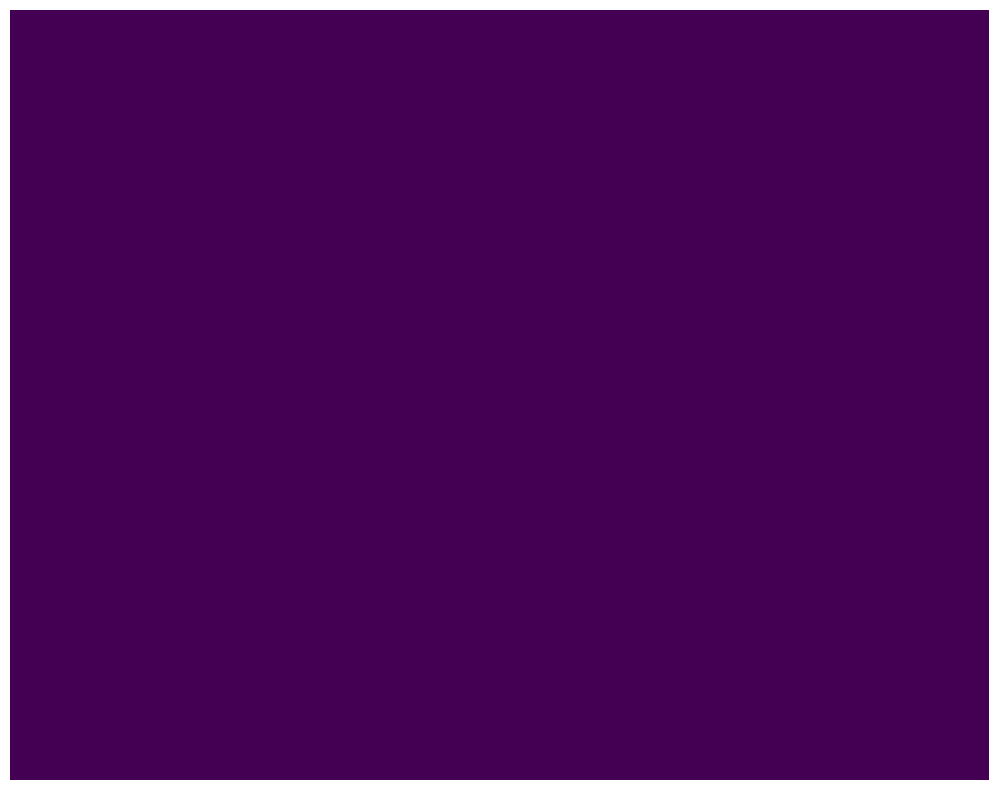

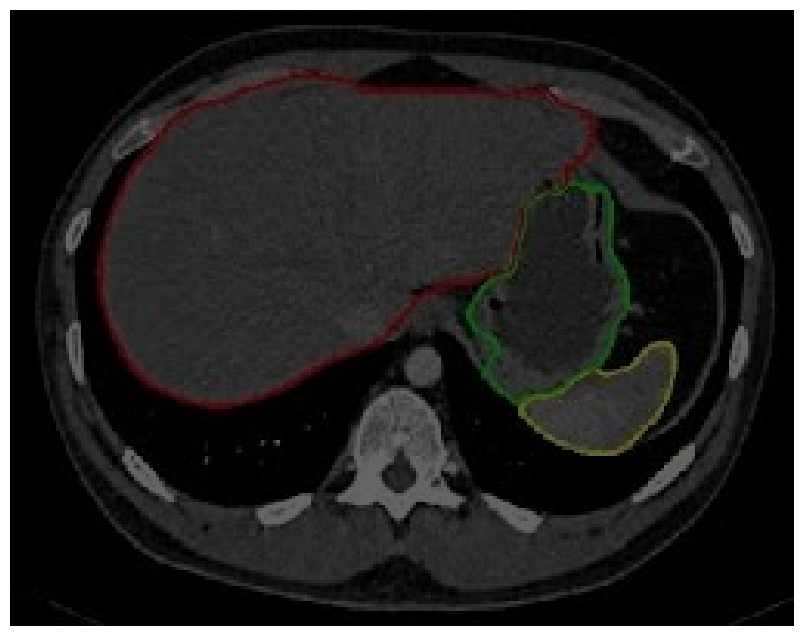

In [5]:
# Panoptic segmentation
panoptic_results, loaded_image, segmentation_instance = perform_panoptic_segmentation(url)

# Visualize
plot_segmentation_labels(panoptic_results, segmentation_instance)
render_segmentation_overlay(panoptic_results, loaded_image, segmentation_instance, transparency=0.6)
